# Análise Analítica de Cavidades Retangulares

Este notebook calcula os parâmetros fundamentais de uma cavidade ressonante retangular para os modos Transversos Elétricos ($TE_{mnl}$) e visualiza a distribuição de campos e os parâmetros de espalhamento (S-Parameters).

## 1. Frequência de Ressonância
A frequência de ressonância para um modo genérico $TE_{mnl}$ (ou $TM_{mnl}$) em uma cavidade preenchida com material dielétrico é dada pela equação de autovalores de Helmholtz:

$$f_{mnl}=\frac{c}{2\pi\sqrt{\mu_r\epsilon_r}}\sqrt{\left(\frac{m\pi}{a}\right)^2+\left(\frac{n\pi}{b}\right)^2+\left(\frac{l\pi}{d}\right)^2}$$

Onde $a$, $b$ e $d$ são a largura, altura e comprimento da cavidade, respectivamente.

## 2. Distribuição do Campo Elétrico (Modos TE)
Para modos $TE_{mnl}$ ($E_z = 0$), as componentes do campo elétrico transversais variam espacialmente segundo as funções trigonométricas impostas pelas condições de contorno de condutor elétrico perfeito (PEC) nas paredes metálicas. A magnitude das componentes é proporcional a:

$$E_x\propto-\frac{n}{b}\cos\left(\frac{m\pi x}{a}\right)\sin\left(\frac{n\pi y}{b}\right)\sin\left(\frac{l\pi z}{d}\right)$$

$$E_y\propto\frac{m}{a}\sin\left(\frac{m\pi x}{a}\right)\cos\left(\frac{n\pi y}{b}\right)\sin\left(\frac{l\pi z}{d}\right)$$

A intensidade (magnitude) total do campo elétrico transversal que visualizaremos nos mapas de cor é calculada pelo módulo do vetor:

$$|E|=\sqrt{|E_x|^2+|E_y|^2}$$

## 3. Fator de Qualidade ($Q$)
O fator de qualidade total de um ressonador considera as perdas no dielétrico ($Q_d$) e as perdas no condutor ($Q_c$):

$$\frac{1}{Q_{total}}=\frac{1}{Q_c}+\frac{1}{Q_d}$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import scipy.constants as sc
import skrf as rf
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# %matplotlib inline

class CavidadeRetangular:
    def __init__(self, a, b, d, er=1.0, tand=0.0, sigma=5.8e7):
        """
        a, b, d: Dimensões em metros (x, y, z)
        er: Permissividade relativa do dielétrico
        tand: Tangente de perdas do dielétrico
        sigma: Condutividade das paredes metálicas (S/m)
        """
        self.a = a
        self.b = b
        self.d = d
        self.er = er
        self.tand = tand
        self.sigma = sigma
        
        self.mu_0 = sc.mu_0
        self.epsilon_0 = sc.epsilon_0
        self.c = sc.c / np.sqrt(er)
        
    def freq_ressonancia(self, m, n, l):
        """Calcula a frequência de ressonância analítica para o modo TE_mnl"""
        kx = m * np.pi / self.a
        ky = n * np.pi / self.b
        beta = l * np.pi / self.d
        f_res = (self.c / (2 * np.pi)) * np.sqrt(kx**2 + ky**2 + beta**2)
        return f_res

    def calcular_Q(self, m, n, l):
        """Calcula os fatores de qualidade aproximados"""
        f0 = self.freq_ressonancia(m, n, l)
        w0 = 2 * np.pi * f0
        
        Q_die = 1.0 / self.tand if self.tand > 0 else float('inf')
        rs = np.sqrt((w0 * self.mu_0) / (2 * self.sigma))
        
        # Aproximação exata para TE101, fallback genérico para outros
        if m==1 and n==0 and l==1:
            num = (self.c * self.mu_0 * np.pi) * (self.a**3 * self.b * self.d**3) * ( (1/self.a**2) + (1/self.d**2) )**(1.5)
            den = 4 * rs * ( (self.a**3 * self.b) + (self.d**3 * self.b) + 0.5*(self.a**3 * self.d) + 0.5*(self.a * self.d**3) )
            Q_cond = num / den
        else:
            Q_cond = 2 * (w0 * self.mu_0) / (rs * (2/self.b + 2/self.a + 2/self.d))
            
        Q_total = Q_cond if Q_die == float('inf') else 1 / (1/Q_cond + 1/Q_die)
        return Q_cond, Q_die, Q_total

print("Classe e bibliotecas carregadas!")

Classe e bibliotecas carregadas!


In [2]:
def plotar_geometria_cavidade(cavidade):
    """Plota a estrutura 3D da cavidade e a localização conceitual das portas"""
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    a, b, d = cavidade.a, cavidade.b, cavidade.d
    
    vertices = np.array([
        [0, 0, 0], [a, 0, 0], [a, b, 0], [0, b, 0],
        [0, 0, d], [a, 0, d], [a, b, d], [0, b, d]
    ])
    
    faces = [
        [vertices[0], vertices[1], vertices[2], vertices[3]], 
        [vertices[4], vertices[5], vertices[6], vertices[7]], 
        [vertices[0], vertices[1], vertices[5], vertices[4]], 
        [vertices[2], vertices[3], vertices[7], vertices[6]], 
        [vertices[0], vertices[3], vertices[7], vertices[4]], 
        [vertices[1], vertices[2], vertices[6], vertices[5]]  
    ]
    
    ax.add_collection3d(Poly3DCollection(faces, facecolors='cyan', linewidths=1, edgecolors='darkcyan', alpha=0.15))
    
    p1 = np.array([[a/2 - a*0.15, b/2 - b*0.15, 0], [a/2 + a*0.15, b/2 - b*0.15, 0], 
                   [a/2 + a*0.15, b/2 + b*0.15, 0], [a/2 - a*0.15, b/2 + b*0.15, 0]])
    p2 = np.array([[a/2 - a*0.15, b/2 - b*0.15, d], [a/2 + a*0.15, b/2 - b*0.15, d], 
                   [a/2 + a*0.15, b/2 + b*0.15, d], [a/2 - a*0.15, b/2 + b*0.15, d]])
    
    ax.add_collection3d(Poly3DCollection([p1], facecolors='red', edgecolors='r', alpha=0.8))
    ax.add_collection3d(Poly3DCollection([p2], facecolors='orange', edgecolors='orange', alpha=0.8))
    
    ax.set_title("Geometria da Cavidade Retangular e Portas")
    ax.set_xlabel('Largura (a) [m]')
    ax.set_ylabel('Altura (b) [m]')
    ax.set_zlabel('Comprimento (d) [m]')
    ax.set_xlim(0, a); ax.set_ylim(0, b); ax.set_zlim(0, d)
    
    legend_elements = [patches.Patch(color='red', alpha=0.8, label='Porta 1 (z=0)'),
                       patches.Patch(color='orange', alpha=0.8, label='Porta 2 (z=d)')]
    ax.legend(handles=legend_elements, loc='upper left')
    plt.show()


def plotar_cortes_campo(cavidade, m=1, n=0, l=1, tipo_modo='TE'):
    """Plota mapas de cores do módulo do campo elétrico para modos TE ou TM"""
    # Validação rigorosa para modos TM (m e n não podem ser zero)
    if tipo_modo.upper() == 'TM' and (m == 0 or n == 0):
        print(f"Erro: Modos TM requerem m > 0 e n > 0. O modo TM_{m}{n}{l} não existe.")
        return

    x = np.linspace(0, cavidade.a, 200)
    y = np.linspace(0, cavidade.b, 100)
    z = np.linspace(0, cavidade.d, 200)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Determinar planos de corte automáticos para pegar os máximos do campo
    y_corte = cavidade.b / (2 * max(1, n)) if n != 0 else cavidade.b / 2
    z_corte = cavidade.d / (2 * max(1, l)) if l != 0 else cavidade.d / 2
    
    X_xz, Z_xz = np.meshgrid(x, z)
    X_xy, Y_xy = np.meshgrid(x, y)
    
    if tipo_modo.upper() == 'TE':
        # --- EQUAÇÕES MODO TE ---
        # Plano XZ (y = constante)
        Ex_xz = -(n/cavidade.b) * np.cos(m*np.pi*X_xz/cavidade.a) * np.sin(n*np.pi*y_corte/cavidade.b) * np.sin(l*np.pi*Z_xz/cavidade.d)
        Ey_xz =  (m/cavidade.a) * np.sin(m*np.pi*X_xz/cavidade.a) * np.cos(n*np.pi*y_corte/cavidade.b) * np.sin(l*np.pi*Z_xz/cavidade.d)
        Ez_xz = 0
        
        # Plano XY (z = constante)
        Ex_xy = -(n/cavidade.b) * np.cos(m*np.pi*X_xy/cavidade.a) * np.sin(n*np.pi*Y_xy/cavidade.b) * np.sin(l*np.pi*z_corte/cavidade.d)
        Ey_xy =  (m/cavidade.a) * np.sin(m*np.pi*X_xy/cavidade.a) * np.cos(n*np.pi*Y_xy/cavidade.b) * np.sin(l*np.pi*z_corte/cavidade.d)
        Ez_xy = 0

    elif tipo_modo.upper() == 'TM':
        # --- EQUAÇÕES MODO TM ---
        kx = m * np.pi / cavidade.a
        ky = n * np.pi / cavidade.b
        kz = l * np.pi / cavidade.d
        kc2 = kx**2 + ky**2
        
        # Plano XZ (y = constante)
        Ex_xz = -(kx * kz / kc2) * np.cos(kx * X_xz) * np.sin(ky * y_corte) * np.sin(kz * Z_xz)
        Ey_xz = -(ky * kz / kc2) * np.sin(kx * X_xz) * np.cos(ky * y_corte) * np.sin(kz * Z_xz)
        Ez_xz = np.sin(kx * X_xz) * np.sin(ky * y_corte) * np.cos(kz * Z_xz)
        
        # Plano XY (z = constante)
        Ex_xy = -(kx * kz / kc2) * np.cos(kx * X_xy) * np.sin(ky * Y_xy) * np.sin(kz * z_corte)
        Ey_xy = -(ky * kz / kc2) * np.sin(kx * X_xy) * np.cos(ky * Y_xy) * np.sin(kz * z_corte)
        Ez_xy = np.sin(kx * X_xy) * np.sin(ky * Y_xy) * np.cos(kz * z_corte)

    # Cálculo da magnitude total
    magnitude_xz = np.sqrt(Ex_xz**2 + Ey_xz**2 + Ez_xz**2)
    magnitude_xy = np.sqrt(Ex_xy**2 + Ey_xy**2 + Ez_xy**2)
    
    # Renderização
    im1 = ax1.pcolormesh(Z_xz, X_xz, magnitude_xz, shading='auto', cmap='jet')
    ax1.set_title(f"|E| no Plano XZ (Corte em y = {y_corte*100:.2f} cm)")
    ax1.set_xlabel("Comprimento (z) [m]")
    ax1.set_ylabel("Largura (x) [m]")
    fig.colorbar(im1, ax=ax1, label="Intensidade Relativa do Campo")
    
    im2 = ax2.pcolormesh(X_xy, Y_xy, magnitude_xy, shading='auto', cmap='jet')
    ax2.set_title(f"|E| no Plano XY (Corte em z = {z_corte*100:.2f} cm)")
    ax2.set_xlabel("Largura (x) [m]")
    ax2.set_ylabel("Altura (b) [m]")
    fig.colorbar(im2, ax=ax2, label="Intensidade Relativa do Campo")
    
    fig.suptitle(f"Distribuição do Módulo do Campo Elétrico - Modo {tipo_modo}_{m}{n}{l}", fontsize=14, y=1.05)
    plt.tight_layout()
    plt.show()

def plotar_parametros_s(cavidade, m=1, n=0, l=1, fc_span=0.05e9):
    """Gera parâmetros S ao redor da frequência de ressonância do modo escolhido"""
    f0 = cavidade.freq_ressonancia(m, n, l)
    _, _, Q = cavidade.calcular_Q(m, n, l)
    
    freqs = np.linspace(f0 - fc_span, f0 + fc_span, 1000)
    s21 = 1 / (1 + 1j * Q * (freqs / f0 - f0 / freqs))
    s11 = np.sqrt(1 - np.abs(s21)**2)
    
    ntw = rf.Network()
    ntw.f = freqs
    ntw.s = np.zeros((len(freqs), 2, 2), dtype=complex)
    ntw.s[:, 0, 0] = s11
    ntw.s[:, 1, 0] = s21
    ntw.s[:, 0, 1] = s21
    ntw.s[:, 1, 1] = s11
    
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    ntw.plot_s_db(m=1, n=0, label=f"$S_{{21}}$ ($TE_{{{m}{n}{l}}}$)")
    ntw.plot_s_db(m=0, n=0, label=f"$S_{{11}}$ ($TE_{{{m}{n}{l}}}$)")
    plt.title(f"Parâmetros S (dB) - Modo $TE_{{{m}{n}{l}}}$")
    plt.grid(True)
    
    plt.subplot(1, 2, 2)
    ntw.plot_s_smith(m=0, n=0)
    plt.title("Carta de Smith ($S_{11}$)")
    
    plt.tight_layout()
    plt.show()

Modo Selecionado: TE_201
Frequência de Ressonância: 6.1886 GHz



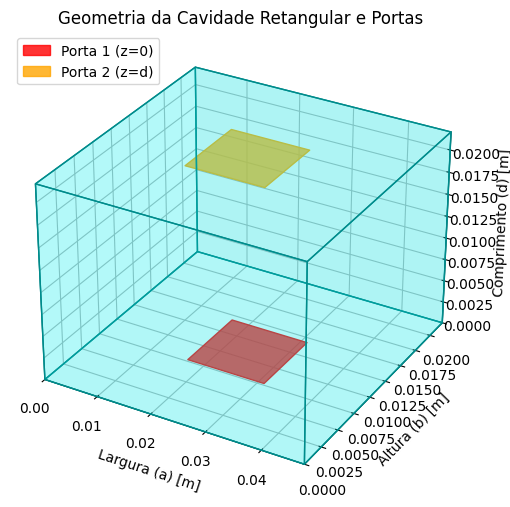

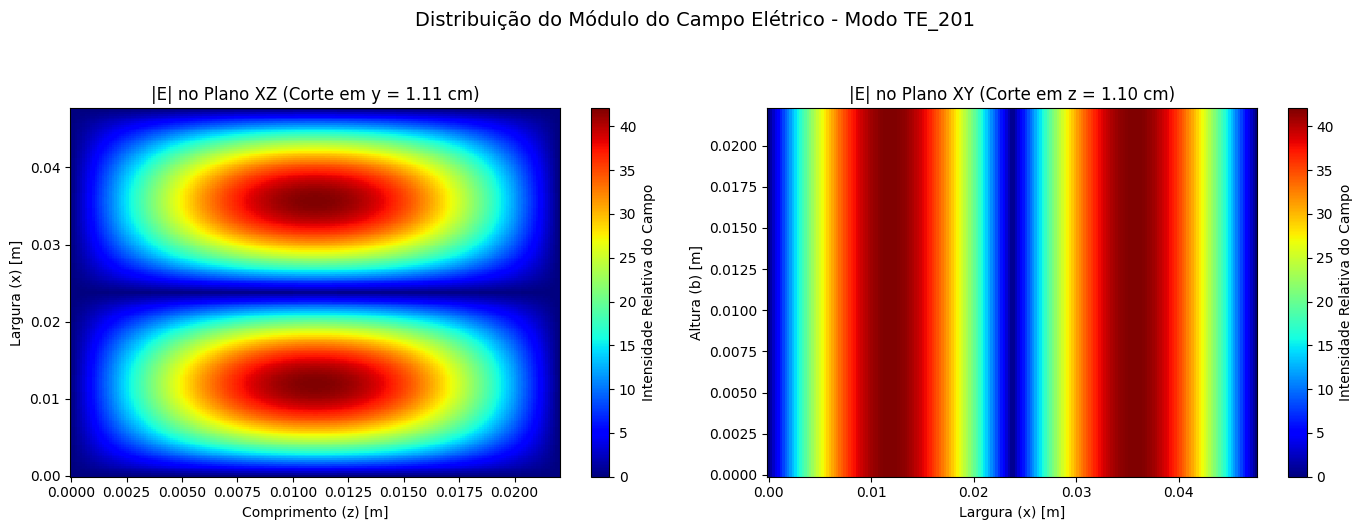

C:\Users\filip\AppData\Local\Temp\ipykernel_127336\2403706933.py:123: DeprecationWarning: frequency.f parameter will be immutable in the next release.
  ntw.f = freqs


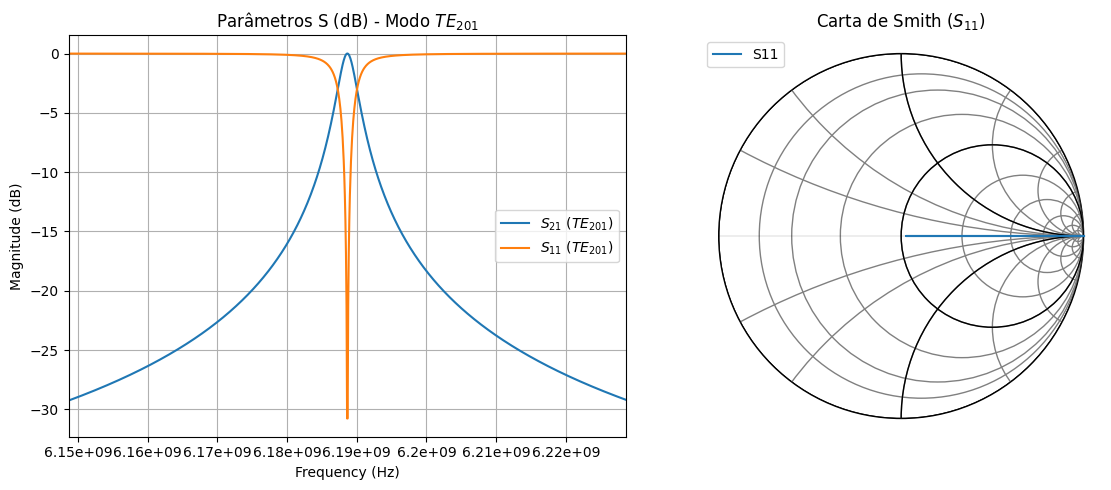

In [14]:
# 1. Definições da Cavidade (Exemplo H-Band do Pozar)
a_cm, b_cm, d_cm = 4.755, 2.215, 2.20
er = 2.25
tangente_perdas = 4e-4
condutividade_cobre = 5.8e7

# Instanciando o objeto cavidade
cav = CavidadeRetangular(a=a_cm*sc.centi, b=b_cm*sc.centi, d=d_cm*sc.centi, 
                         er=er, tand=tangente_perdas, sigma=condutividade_cobre)

# ----------------------------------------------------
# 2. ESCOLHA O MODO E O TIPO (TE ou TM)
# ----------------------------------------------------
m_modo = 2
n_modo = 0
l_modo = 1
tipo = 'TE'  # Mude para 'TE' ou 'TM'

f_res = cav.freq_ressonancia(m_modo, n_modo, l_modo)
print(f"==========================================")
print(f"Modo Selecionado: {tipo}_{m_modo}{n_modo}{l_modo}")
print(f"Frequência de Ressonância: {f_res/1e9:.4f} GHz")
print(f"==========================================\n")

# 3. Renderizando as análises
plotar_geometria_cavidade(cav)
plotar_cortes_campo(cav, m=m_modo, n=n_modo, l=l_modo, tipo_modo=tipo)
plotar_parametros_s(cav, m=m_modo, n=n_modo, l=l_modo, fc_span=0.04e9)